In [1]:
from pathlib import Path
import subprocess

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

import config

from dimelo import parse_bam, load_processed, plot_read_browser
import config, utils

import memray
import cProfile
import pstats

In [2]:
modkit_exe = Path("/Users/jeremy/devspace/cargo_local/bin/modkit")

# Starting with chr11 as a test (the pileup for the browser happens to be all of chr11)
pileup_file = config.processed_data_dir / "pileup.20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.browser" / "pileup.sorted.bed.gz"
ctcf_chip_seq_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_ctcf_chip_peaks.bed")
# tss_file = Path("/Users/jeremy/devspace/multimodal-dimelo/review_data/chr11_q4_tss.slop250.bed")
window_file = Path("/Users/jeremy/devspace/reference_data/beds/chm13v2.0_windows_1000bp/chm13v2.0_windows_1000bp_chr11.bed")


output_dir = config.working_dir / "review_data"

modkit_stats_file = output_dir / "modkit_stats_chr11_1000bp.tsv"
label_file = output_dir / "window_labels_chr11_1000bp.tsv"
ctcf_chip_window_assignment_file = output_dir / "ctcf_chip_assignments_chr11_1000bp.tsv"

ctcf_chip_peak_file = config.processed_data_dir / "ENCFF797SDL.t2t_chm13v2.bed"
genome_index_file = config.raw_data_dir / "chm13v2.0.fa.fai"
genome_file = config.raw_data_dir / "chm13v2.0.fa"
ctcf_bam_file = config.processed_data_dir / "20240923_dimelo_access_background.dorado_v102_sup_v500_5mC_5hmC_v3_6mA_v3.trim.align.filtered.q10.bam"

output_dir = config.working_dir / "review_data" / "single_read"
ctcf_chip_peak_centers_file = output_dir / ctcf_chip_peak_file.with_suffix(".centers.bed").name
ctcf_peak_regions_file =  output_dir / ctcf_chip_peak_file.with_suffix(".regions.bed").name

ctcf_output_id = f"{ctcf_bam_file.stem}.{ctcf_peak_regions_file.stem}.5motifs"
# 400 / 2
window_size = 200
motifs = ["A,0", "WCG,1", "GCH,1", "CG,0","SCG,1"]
n_cores = 10
thresh = 0.75

In [3]:
# # TODO: Use this in the third party data notebook; way quicker
# subprocess.run(f"awk -F '\t' 'BEGIN {{OFS=FS}} {{midpoint = int(($3 + $2) / 2); $2 = midpoint; $3 = midpoint + 1; print}}' {ctcf_chip_peak_file} > {ctcf_chip_peak_centers_file}", shell=True)
# subprocess.run(f"bedtools slop -i {ctcf_chip_peak_centers_file} -g {genome_index_file} -b {window_size}  > {ctcf_peak_regions_file}", shell=True)

In [4]:
# parse_bam.extract(
#     input_file=ctcf_bam_file,
#     output_name=f"extract.{ctcf_output_id}",
#     ref_genome=genome_file,
#     output_directory=output_dir,
#     regions=ctcf_peak_regions_file,
#     motifs=motifs,
#     thresh=None, # TODO: No thresholding at extract time?
#     cores=n_cores,
#     override_checks=True,
#     window_size=1500,
# )

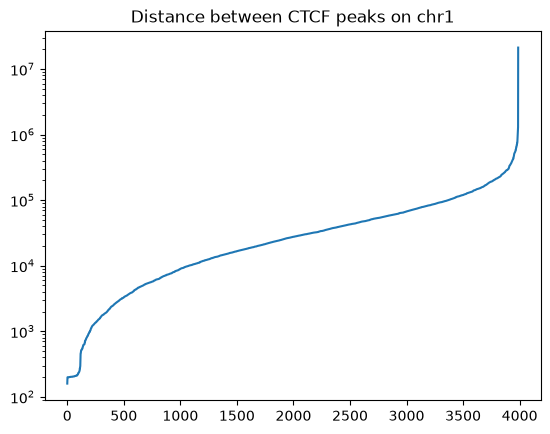

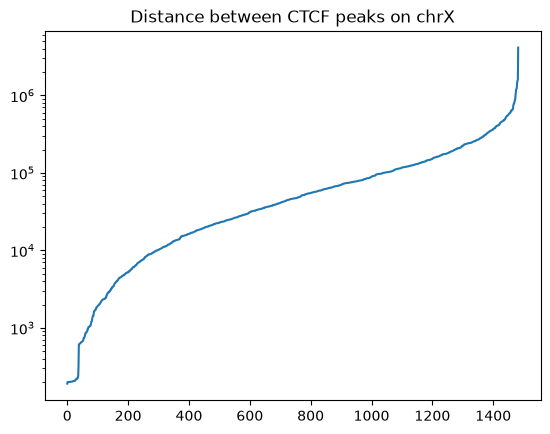

In [5]:
target_chroms = ["chr1","chrX"]

# chrom_tag = ",".join(target_chroms)
# target_file = output_dir / ctcf_chip_peak_file.with_suffix(f".regions.{chrom_tag}.bed").name

# awk_set = " || ".join(f'$1 == "{c}"' for c in target_chroms)
# subprocess.run(f"awk '{awk_set}' {ctcf_peak_regions_file} > {target_file}", shell=True)
# ctcf_peak_regions_file = target_file

ctcf_peak_regions_files = {}
regions_dfs = {}
for target_chrom in target_chroms:
    # Temporarily just look at one chromosome for speed and memory
    target_file = output_dir / ctcf_chip_peak_file.with_suffix(f".regions.{target_chrom}.bed").name
    subprocess.run(f"awk '$1 == \"{target_chrom}\"' {ctcf_peak_regions_file} > {target_file}", shell=True)
    ctcf_peak_regions_files[target_chrom] = target_file

    regions_df = utils.load_encode_narrowpeak_bed(ctcf_peak_regions_files[target_chrom])
    regions_df["window_spec"] = regions_df["chrom"] + ":" + regions_df["chromStart"].astype("str") + "-" + regions_df["chromEnd"].astype("str")
    regions_dfs[target_chrom] = regions_df
    regions_df["chromStart"].sort_values().diff().sort_values(ignore_index=True).plot(logy=True, title=f"Distance between CTCF peaks on {target_chrom}")
    plt.show()

In [6]:
motif_read_region_mod_fracs_dict = {}

for target_chrom, ctcf_peak_regions_file, regions_df in zip(target_chroms, ctcf_peak_regions_files.values(), regions_dfs.values()):
    load_window_size = 100
    sorted_read_data_converted, datasets, regions_dict = load_processed.read_vectors_from_hdf5(
        file=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
        motifs=motifs,
        regions=ctcf_peak_regions_file,
        window_size=load_window_size,
        calculate_mod_fractions=False,
        span_full_window=True,
    )
    centers = (regions_df["chromStart"] + regions_df["chromEnd"]) // 2
    regions_df = regions_df.assign(
        chromStart=centers - load_window_size,
        chromEnd=centers + load_window_size,
    )
    read_data_by_motif = {motif: [] for motif in motifs}
    for read_tuple in sorted_read_data_converted:
        read_data_by_motif[read_tuple[datasets.index("motif")]].append(read_tuple)
    read_data_by_motif_filtered = {motif: [] for motif in motifs}
    for motif in motifs:
        seen = set()
        for read_tuple in read_data_by_motif[motif]:
            read_name = read_tuple[datasets.index("read_name")]
            if read_name not in seen:
                read_data_by_motif_filtered[motif].append(read_tuple)
                seen.add(read_name)
    motif_read_region_mod_fracs = {}
    for motif in motifs:
        # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
        read_dfs = []
        for read_tuple in read_data_by_motif_filtered[motif]:
            overlapping_regions = regions_df[(regions_df["chromStart"] >= read_tuple[datasets.index("read_start")]) & (regions_df["chromEnd"] <= read_tuple[datasets.index("read_end")])]

            mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
            read_region_indices = (overlapping_regions[["chromStart", "chromEnd"]] - read_tuple[datasets.index("read_start")])
            mod_counts = read_region_indices.apply(lambda row: mod_vec[row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
            valid_counts = read_region_indices.apply(lambda row: read_tuple[datasets.index("val_vector")][row["chromStart"]: row["chromEnd"]].sum(), axis="columns")
            read_df = pd.concat([(mod_counts/valid_counts).rename("mod_frac"), overlapping_regions["window_spec"], valid_counts.rename("valid_counts")], axis="columns")
            read_df["read_name"] = read_tuple[datasets.index("read_name")]
            read_dfs.append(read_df)
        motif_read_region_mod_fracs[motif] = pd.concat(read_dfs)
    motif_read_region_mod_fracs_dict[target_chrom] = motif_read_region_mod_fracs

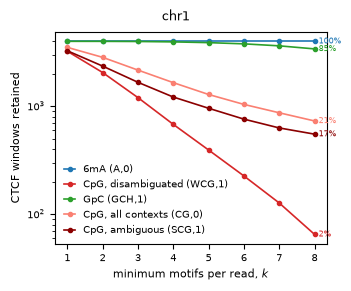

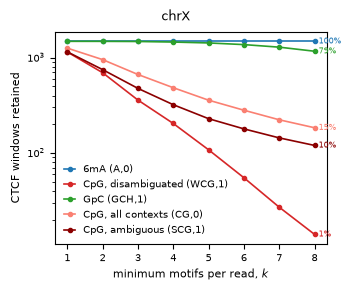

/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/oberon/miniconda3/envs/multimodal_dimelo/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


chr1 AvWCG: sites=842
chr1 AvGCH: sites=3972
chr1 GCHvWCG: sites=838
chr1 AvSCG: sites=1636
chr1 AvGCH: sites=3972
chr1 GCHvSCG: sites=1631


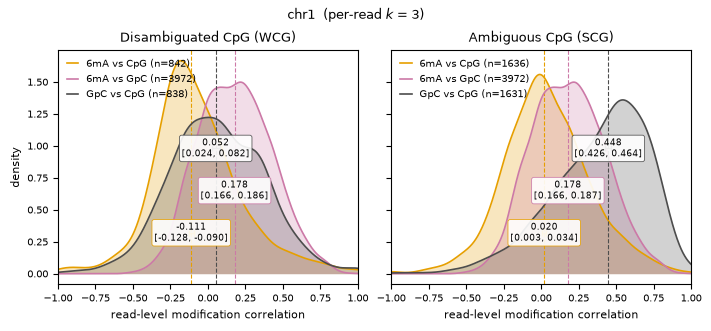

chrX AvWCG: sites=287
chrX AvGCH: sites=1475
chrX GCHvWCG: sites=289
chrX AvSCG: sites=468
chrX AvGCH: sites=1475
chrX GCHvSCG: sites=467


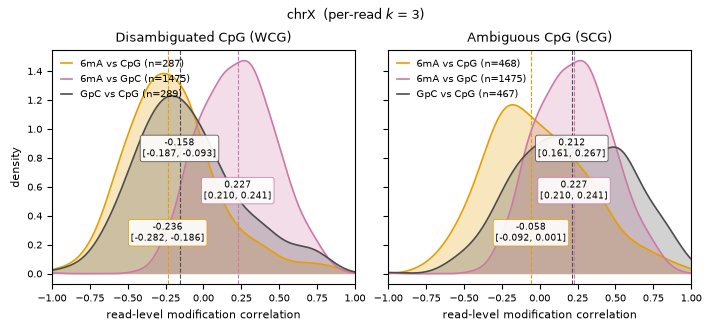

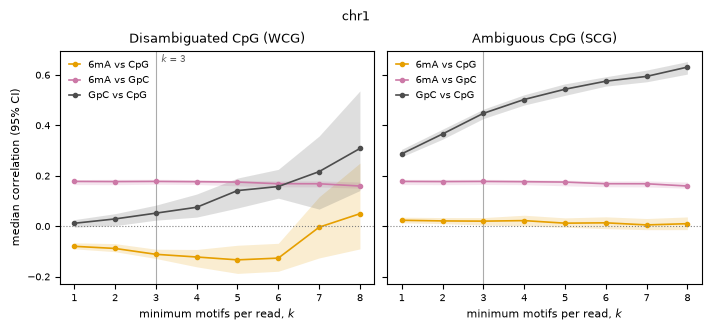

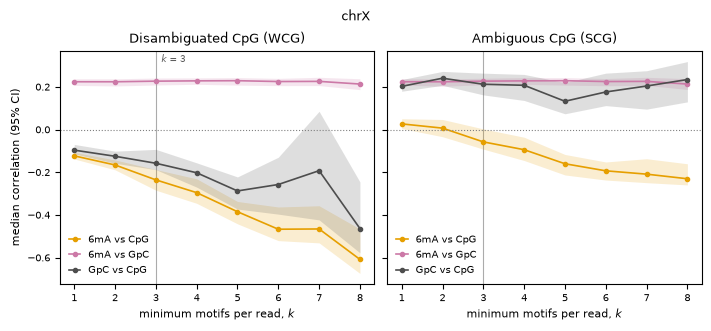

In [10]:
# ------------------------------------------------------- preprint-matched style
# dimelo-toolkit figures are default-matplotlib (tab10, boxed axes). Keep that
# so this supp panel sits consistently alongside Figs 2-5; Arial for submission
# with DejaVu Sans fallback to visually match the existing panels if Arial absent.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 9,
    "figure.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "legend.frameon": False,
    "axes.linewidth": 0.8,          # keep all four spines (paper is boxed)
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "lines.linewidth": 1.2,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,             # editable text in Illustrator, not outlines
    "ps.fonttype": 42,
})

# ------------------------------------------------------------------ config
depth = 0
CORR_DIST_K = 3          # set to 1 to show the minimally-selected slice
valid_A_counts = CORR_DIST_K
valid_C_counts = CORR_DIST_K
SHUFFLE = False        # True -> plot a single within-window shuffled null instead
SHUFFLE_SEED = 1

# bootstrap CI on the per-comparison median
N_BOOT = 2000
CI = 95
BOOT_SEED = 0

# motif-count threshold sweep range (also used by the locus-retention figure)
MOTIF_COUNT_MIN = 1
MOTIF_COUNT_MAX = 8          # <-- hyperparameter: sweep MIN..MAX inclusive
MOTIF_COUNTS = range(MOTIF_COUNT_MIN, MOTIF_COUNT_MAX + 1)

# vector-panel export for figure assembly
SAVE_FIG = True
FIG_DIR = "single_read_supp"

A_motif  = "A,0";    A_name  = "A"      # internal names double as merge suffixes
GC_motif = "GCH,1";  GC_name = "GCH"    # -> keep short/ascii; display names below

# the two CpG channels compared side by side: (motif, merge-name, panel subtitle)
cpg_panels = [
    ("WCG,1", "WCG", "Disambiguated CpG (WCG)"),
    ("SCG,1", "SCG", "Ambiguous CpG (SCG)"),
]

# --- preprint color/label grammar -------------------------------------------
# Per-channel identity (retention panel): blue/green/red per the preprint.
# The three CpG variants share a red family but are luminance-separated so
# CG,0 / WCG,1 / SCG,1 don't read as the same line.
CHANNEL_STYLE = {                       # motif code -> (legend label, color)
    "A,0":   ("6mA (A,0)",                  "tab:blue"),
    "GCH,1": ("GpC (GCH,1)",                "tab:green"),
    "CG,0":  ("CpG, all contexts (CG,0)",   "salmon"),    # light red
    "WCG,1": ("CpG, disambiguated (WCG,1)", "tab:red"),   # canonical (matches paper)
    "SCG,1": ("CpG, ambiguous (SCG,1)",     "darkred"),   # dark red
}
# Fallback for any motif not listed above: reserved-free hues so nothing
# collides with the blue/green/red channel scheme.
_FALLBACK = ["tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
# Short names for pairwise legends; a correlation line is a *pair* of channels.
DISPLAY = {"A": "6mA", "GCH": "GpC", "WCG": "CpG", "SCG": "CpG"}
# Neutral triad, deliberately distinct from the channel blue/green/red.
COMPARISON_COLORS = ["#E69F00", "#CC79A7", "#4D4D4D"]  # 6mA-CpG, 6mA-GpC, GpC-CpG

def channel_style(code, idx):
    if code in CHANNEL_STYLE:
        return CHANNEL_STYLE[code]
    return (code, _FALLBACK[idx % len(_FALLBACK)])

KDE_GRID = np.linspace(-1, 1, 512)
BOX_Y = [0.22, 0.40, 0.58]   # staggered annotation heights, one per comparison

# --------------------------------------------------------------- functions
def save_panel(fig, name):
    if SAVE_FIG:
        import os
        os.makedirs(FIG_DIR, exist_ok=True)
        fig.savefig(f"{FIG_DIR}/{name}.svg")

def window_correlations(df, col_x, col_y, depth):
    def _r(g):
        if len(g) < depth:
            return np.nan
        return g[col_x].corr(g[col_y])
    return df.groupby("window_spec")[[col_x, col_y]].apply(_r).dropna()

def bootstrap_median_ci(values, n_boot, ci, rng):
    """Percentile bootstrap CI for the median."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    med = float(np.median(values)) if n else np.nan
    if n < 2:
        return med, med, med
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_meds = np.median(values[idx], axis=1)
    lo, hi = np.percentile(boot_meds, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return med, float(lo), float(hi)

def loci_retained_curve(df, ks):
    """# windows retained vs k. A window is retained at threshold k iff it
    keeps >= max(depth, 1) reads with valid_counts >= k. Ties to your existing
    `depth`; the floor of 1 just stops an empty window from counting itself."""
    min_keep = max(depth, 1)
    def keep_thresh(s):
        v = s.values
        if len(v) < min_keep:
            return -1
        return np.partition(v, -min_keep)[-min_keep]   # min_keep-th largest count
    thresh = df.groupby("window_spec")["valid_counts"].apply(keep_thresh).values
    return np.array([(thresh >= k).sum() for k in ks])

def kde_with_median(ax, values, color, label, y_frac, boot_rng):
    """Filled KDE on [-1, 1] + dashed median line + compact median/CI box."""
    values = np.asarray(values, dtype=float)
    med, lo, hi = bootstrap_median_ci(values, N_BOOT, CI, boot_rng)
    ax.axvline(med, color=color, linestyle="--", linewidth=0.8)

    leg = f"{label} (n={len(values)})"
    if len(values) >= 2 and np.ptp(values) > 0:      # gaussian_kde needs spread
        dens = gaussian_kde(values)(KDE_GRID)
        ax.fill_between(KDE_GRID, dens, color=color, alpha=0.25, linewidth=0)
        ax.plot(KDE_GRID, dens, color=color, linewidth=1.2, label=leg)
    else:                                            # degenerate -> legend entry only
        ax.plot([], [], color=color, linewidth=1.2, label=leg)

    trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        ax.errorbar(med, y_frac, xerr=[[med - lo], [hi - med]], transform=trans,
                    color=color, fmt="none", capsize=2.5, elinewidth=1.0,
                    capthick=1.0, zorder=4)
    ax.text(med, y_frac, f"{med:.3f}\n[{lo:.3f}, {hi:.3f}]", transform=trans,
            ha="center", va="center", fontsize=6.5, zorder=5,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor=color, linewidth=0.6, alpha=0.9))

def panel_comparisons(cpg_motif, cpg_name):
    """Three pairwise comparisons for a given CpG channel choice. Colors are the
    neutral triad (not the per-channel blue/green/red), since each line is a pair.
    (left_motif, left_name, right_motif, right_name, min_left, min_right, color, label)"""
    lab = lambda a, b: f"{DISPLAY[a]} vs {DISPLAY[b]}"
    return [
        (A_motif,  A_name,  cpg_motif, cpg_name, valid_A_counts, valid_C_counts, COMPARISON_COLORS[0], lab(A_name,  cpg_name)),
        (A_motif,  A_name,  GC_motif,  GC_name,  valid_A_counts, valid_C_counts, COMPARISON_COLORS[1], lab(A_name,  GC_name)),
        (GC_motif, GC_name, cpg_motif, cpg_name, valid_C_counts, valid_C_counts, COMPARISON_COLORS[2], lab(GC_name, cpg_name)),
    ]

def compute_and_plot(ax, motif_read_region_mod_fracs, comparisons, boot_rng, shuffle_rng, target_chrom):
    for i, (left_motif, left_name, right_motif, right_name,
            min_left, min_right, color, label) in enumerate(comparisons):

        merged = pd.merge(
            motif_read_region_mod_fracs[left_motif],
            motif_read_region_mod_fracs[right_motif],
            how="inner", on=["window_spec", "read_name"],
            suffixes=[f"_{left_name}", f"_{right_name}"],
        )
        merged = merged[
            (merged[f"valid_counts_{left_name}"]  >= min_left)
            & (merged[f"valid_counts_{right_name}"] >= min_right)
        ]

        col_x, col_y = f"mod_frac_{left_name}", f"mod_frac_{right_name}"

        if SHUFFLE:
            merged = merged.copy()
            merged[col_y] = merged.groupby("window_spec")[col_y].transform(
                lambda s: shuffle_rng.permutation(s.values)
            )

        corrs = window_correlations(merged, col_x, col_y, depth)
        print(f"{target_chrom} {left_name}v{right_name}: sites={len(corrs)}")  # caption n's

        if len(corrs) == 0:
            continue
        kde_with_median(ax, corrs.values, color, label, BOX_Y[i], boot_rng)

def merge_comparison(motif_read_region_mod_fracs,
                     left_motif, left_name, right_motif, right_name):
    """Merge the two channels once; per-k threshold filtering happens below."""
    return pd.merge(
        motif_read_region_mod_fracs[left_motif],
        motif_read_region_mod_fracs[right_motif],
        how="inner", on=["window_spec", "read_name"],
        suffixes=[f"_{left_name}", f"_{right_name}"],
    )

def sweep_point(merged, left_name, right_name, k, shuffle_rng, boot_rng):
    """Filter pre-merged frame at threshold k (applied to BOTH channels),
    compute per-window correlations, return (median, lo, hi, n_sites)."""
    sub = merged[
        (merged[f"valid_counts_{left_name}"]  >= k)
        & (merged[f"valid_counts_{right_name}"] >= k)
    ]
    col_x, col_y = f"mod_frac_{left_name}", f"mod_frac_{right_name}"

    if SHUFFLE:
        sub = sub.copy()  # copy so we never mutate `merged` across k values
        sub[col_y] = sub.groupby("window_spec")[col_y].transform(
            lambda s: shuffle_rng.permutation(s.values)
        )

    corrs = window_correlations(sub, col_x, col_y, depth).values
    if len(corrs) == 0:
        return np.nan, np.nan, np.nan, 0
    med, lo, hi = bootstrap_median_ci(corrs, N_BOOT, CI, boot_rng)
    return med, lo, hi, len(corrs)

# =========================================================================
#  Panel: locus retention vs motif-count threshold (one axes per chromosome)
#  Per-channel -> blue/green/red per the preprint convention.
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    ks = np.array(list(MOTIF_COUNTS))
    fig, ax = plt.subplots(figsize=(3.4, 2.8), layout="constrained")
    fig.suptitle(target_chrom)                       # drop for final assembly if lettering panels

    for i, motif in enumerate(motifs):
        label, color = channel_style(motif, i)
        curve = loci_retained_curve(motif_read_region_mod_fracs[motif], ks)
        ax.plot(ks, curve, marker="o", markersize=3, color=color, label=label)
        if curve[0] > 0:                             # % of k=1 loci surviving at k_max
            ax.annotate(f"{curve[-1] / curve[0]:.0%}", (ks[-1], curve[-1]),
                        fontsize=6, color=color,
                        xytext=(3, 0), textcoords="offset points", va="center")
    ax.set_yscale("log")
    ax.set_xlabel(r"minimum motifs per read, $k$")
    ax.set_ylabel("CTCF windows retained")
    ax.set_xticks(list(MOTIF_COUNTS))
    ax.legend(handlelength=1.2)

    save_panel(fig, f"{target_chrom}_locus_retention")
    plt.show()

# =========================================================================
#  Panel: within-window correlation distributions, clean vs confounded CpG
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    fig, axs = plt.subplots(1, 2, figsize=(7.0, 3.2), layout="constrained",
                            sharex=True, sharey=True)
    suptitle = f"{target_chrom}  (per-read $k$ = {CORR_DIST_K})" + \
               ("  [within-window shuffled null]" if SHUFFLE else "")
    fig.suptitle(suptitle)

    boot_rng = np.random.default_rng(BOOT_SEED)
    shuffle_rng = np.random.default_rng(SHUFFLE_SEED)

    for ax, (cpg_motif, cpg_name, subtitle) in zip(axs, cpg_panels):
        ax.set_title(subtitle)
        comparisons = panel_comparisons(cpg_motif, cpg_name)
        compute_and_plot(ax, motif_read_region_mod_fracs, comparisons,
                         boot_rng, shuffle_rng, target_chrom)

    for ax in axs:
        ax.set_xlim((-1, 1))
        ax.set_xlabel("read-level modification correlation")
        ax.legend(loc="upper left", handlelength=1.2)
    axs[0].set_ylabel("density")
    save_panel(fig, f"{target_chrom}_corr_distributions")
    plt.show()

# =========================================================================
#  Panel: median correlation vs motif-count threshold, clean vs confounded CpG
#  Raising k denoises each read's mod_frac -> higher correlation, but drops
#  reads/windows -> wider CI. Retention side of the trade-off is the panel above.
# =========================================================================
for target_chrom, motif_read_region_mod_fracs in motif_read_region_mod_fracs_dict.items():
    fig, axs = plt.subplots(1, len(cpg_panels), figsize=(7.0, 3.2),
                            layout="constrained", sharex=True, sharey=True)
    axs = np.atleast_1d(axs)
    suptitle = f"{target_chrom}" + \
               ("  [within-window shuffled null]" if SHUFFLE else "")
    fig.suptitle(suptitle)

    boot_rng    = np.random.default_rng(BOOT_SEED)
    shuffle_rng = np.random.default_rng(SHUFFLE_SEED)
    ks = np.array(list(MOTIF_COUNTS))

    for col, (cpg_motif, cpg_name, subtitle) in enumerate(cpg_panels):
        ax = axs[col]
        ax.set_title(subtitle)

        for (left_motif, left_name, right_motif, right_name,
             _min_l, _min_r, color, label) in panel_comparisons(cpg_motif, cpg_name):

            merged = merge_comparison(motif_read_region_mod_fracs,
                                      left_motif, left_name, right_motif, right_name)

            meds, los, his = [], [], []
            for k in MOTIF_COUNTS:
                med, lo, hi, _n = sweep_point(
                    merged, left_name, right_name, k, shuffle_rng, boot_rng)
                meds.append(med); los.append(lo); his.append(hi)
            meds, los, his = map(np.array, (meds, los, his))

            ax.plot(ks, meds, color=color, marker="o", markersize=3, label=label)
            ax.fill_between(ks, los, his, color=color, alpha=0.18, linewidth=0)

        ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
        ax.set_xlabel(r"minimum motifs per read, $k$")
        ax.set_xticks(list(MOTIF_COUNTS))

    axs[0].set_ylabel(f"median correlation ({CI}% CI)")
    for ax in axs:
        ax.legend(loc="best", handlelength=1.2)
    for ax in axs:
        ax.axvline(CORR_DIST_K, color="0.35", lw=0.8, ls="-", alpha=0.5, zorder=0)
    axs[0].annotate(f"$k$ = {CORR_DIST_K}", xy=(CORR_DIST_K, 1.0),
                    xycoords=("data", "axes fraction"), xytext=(4, -3),
                    textcoords="offset points", ha="left", va="top",
                    fontsize=6.5, color="0.35")
    save_panel(fig, f"{target_chrom}_threshold_sweep")
    plt.show()

In [8]:
motif_read_sites_mod_fracs_dict = {}

single_ctcf_sites = [
    "chrX:130065302-130065703",  
    "chrX:130065923-130066324",
    "chrX:130070681-130071082",
    "chrX:130071365-130071766",
    "chrX:130076691-130077092",
    "chrX:130077315-130077716",
    # "chrX:130087915-130088316",
    # "chrX:130087021-130087422"
]

for ctcf_site in single_ctcf_sites:
    load_window_size = 100
    sorted_read_data_converted, datasets, regions_dict = load_processed.read_vectors_from_hdf5(
        file=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
        motifs=motifs,
        regions=ctcf_site,
        window_size=load_window_size,
        calculate_mod_fractions=False,
        span_full_window=True,
    )
    _, coords = ctcf_site.split(":")
    site_start, site_end = (int(x) for x in coords.split("-"))
    center = (site_start + site_end) // 2
    window_start = center - load_window_size
    window_end = center + load_window_size

    read_data_by_motif = {motif: [] for motif in motifs}
    for read_tuple in sorted_read_data_converted:
        read_data_by_motif[read_tuple[datasets.index("motif")]].append(read_tuple)

    read_data_by_motif_filtered = {motif: [] for motif in motifs}
    for motif in motifs:
        seen = set()
        for read_tuple in read_data_by_motif[motif]:
            read_name = read_tuple[datasets.index("read_name")]
            if read_name not in seen:
                read_data_by_motif_filtered[motif].append(read_tuple)
                seen.add(read_name)

    motif_read_site_mod_fracs = {}
    for motif in motifs:
        # NOTE: This only works because I'm setting `span_full_window` to True. Otherwise I would need to handle partial overlaps better. Same goes for analysis above.
        rows = []
        for read_tuple in read_data_by_motif_filtered[motif]:
            read_start = read_tuple[datasets.index("read_start")]
            read_end = read_tuple[datasets.index("read_end")]
            # Keep only reads that fully span the window (mirrors the old containment filter)
            if not (window_start >= read_start and window_end <= read_end):
                continue
            mod_vec = read_tuple[datasets.index("mod_vector")] >= thresh
            val_vec = read_tuple[datasets.index("val_vector")]
            rel_start = window_start - read_start
            rel_end = window_end - read_start
            mod_count = mod_vec[rel_start:rel_end].sum()
            valid_count = val_vec[rel_start:rel_end].sum()
            rows.append({
                "mod_frac": mod_count / valid_count,
                "window_spec": ctcf_site,
                "valid_counts": valid_count,
                "read_name": read_tuple[datasets.index("read_name")],
            })
        motif_read_site_mod_fracs[motif] = pd.DataFrame(
            rows, columns=["mod_frac", "window_spec", "valid_counts", "read_name"]
        )
    motif_read_sites_mod_fracs_dict[ctcf_site] = motif_read_site_mod_fracs

/tmp/ipykernel_1282648/4188290968.py:60: RuntimeWarning: invalid value encountered in scalar divide
  "mod_frac": mod_count / valid_count,


In [35]:
for site, per_motif in motif_read_sites_mod_fracs_dict.items():
    print(f"\n{site}")
    for m in ["A,0", "GCH,1", "WCG,1"]:
        vc = per_motif[m]["valid_counts"]
        print(f"  {m:6s}  n={len(vc):3d}  "
              f"min={vc.min():2.0f}  med={vc.median():4.1f}  "
              f"max={vc.max():2.0f}  frac(vc<=3)={np.mean(vc <= 3):.0%}")


chrX:130065302-130065703
  A,0     n= 32  min= 0  med=44.0  max=51  frac(vc<=3)=3%
  GCH,1   n= 32  min= 0  med=10.0  max=10  frac(vc<=3)=3%
  WCG,1   n= 32  min= 0  med= 3.0  max= 3  frac(vc<=3)=100%

chrX:130065923-130066324
  A,0     n= 30  min= 0  med=41.0  max=54  frac(vc<=3)=3%
  GCH,1   n= 30  min= 0  med= 8.0  max=10  frac(vc<=3)=3%
  WCG,1   n= 30  min= 0  med= 3.0  max= 4  frac(vc<=3)=67%

chrX:130070681-130071082
  A,0     n= 28  min= 0  med=41.5  max=53  frac(vc<=3)=4%
  GCH,1   n= 28  min= 0  med= 9.0  max=11  frac(vc<=3)=4%
  WCG,1   n= 28  min= 0  med= 3.0  max= 3  frac(vc<=3)=100%

chrX:130071365-130071766
  A,0     n= 23  min= 0  med=39.0  max=56  frac(vc<=3)=13%
  GCH,1   n= 23  min= 0  med= 6.0  max= 8  frac(vc<=3)=13%
  WCG,1   n= 23  min= 0  med= 3.0  max= 5  frac(vc<=3)=52%

chrX:130076691-130077092
  A,0     n= 23  min=33  med=43.0  max=53  frac(vc<=3)=0%
  GCH,1   n= 23  min= 5  med= 7.0  max= 8  frac(vc<=3)=0%
  WCG,1   n= 23  min= 2  med= 5.0  max= 6  frac(vc

paired n after ≥3-motif filter:
  chrX:130065302-130065703  6mAvCpG=24  6mAvGpC=31  GpCvCpG=24
  chrX:130065923-130066324  6mAvCpG=19  6mAvGpC=29  GpCvCpG=19
  chrX:130070681-130071082  6mAvCpG=18  6mAvGpC=27  GpCvCpG=18
  chrX:130071365-130071766  6mAvCpG=17  6mAvGpC=20  GpCvCpG=17
  chrX:130076691-130077092  6mAvCpG=22  6mAvGpC=23  GpCvCpG=22
  chrX:130077315-130077716  6mAvCpG=0  6mAvGpC=20  GpCvCpG=0


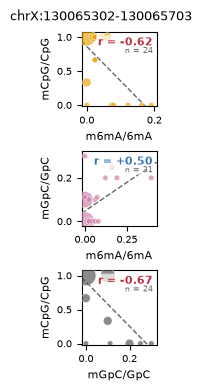

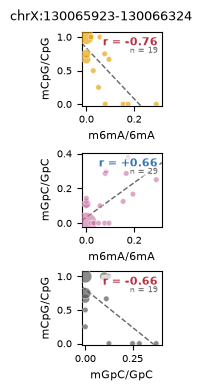

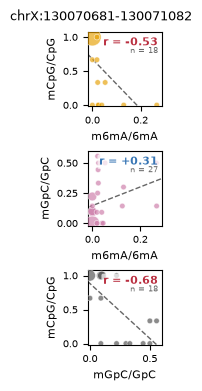

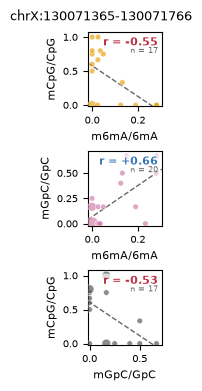

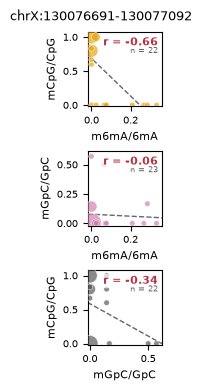

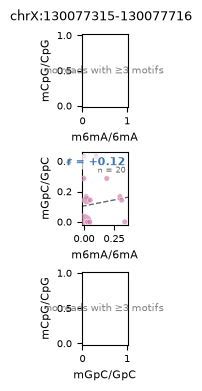

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

COMPARISON_COLORS = ["#E69F00", "#CC79A7", "#4D4D4D"]
A_motif, GC_motif, CPG_motif = "A,0", "GCH,1", "WCG,1"

comparisons = [
    (A_motif,  "6mA", CPG_motif, "CpG", COMPARISON_COLORS[0]),
    (A_motif,  "6mA", GC_motif,  "GpC", COMPARISON_COLORS[1]),
    (GC_motif, "GpC", CPG_motif, "CpG", COMPARISON_COLORS[2]),
]

MIN_VALID = 3
SHOW_FIT = True 
FIT_WEIGHTED = False 


def pair_site(per_motif, mx, my, min_valid=MIN_VALID):
    cols = ["read_name", "mod_frac", "valid_counts"]
    paired = (
        per_motif[mx][cols]
        .merge(per_motif[my][cols], on="read_name", suffixes=("_x", "_y"))
        .dropna(subset=["mod_frac_x", "mod_frac_y"])
    )
    return paired[
        (paired.valid_counts_x >= min_valid) & (paired.valid_counts_y >= min_valid)
    ]


def scatter_pair(ax, paired, nx, ny, color):
    ax.set_xlabel(f"m{nx}/{nx}");
    ax.set_ylabel(f"m{ny}/{ny}");

    x = paired["mod_frac_x"].to_numpy()
    y = paired["mod_frac_y"].to_numpy()

    if len(x) == 0:
        ax.annotate(f"no reads with ≥{MIN_VALID} motifs",
                    xy=(0.5, 0.5), xycoords="axes fraction",
                    ha="center", va="center", fontsize=7, color="0.5")
        ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
        return

    xr, yr = np.round(x, 3), np.round(y, 3)
    pts, counts = np.unique(np.c_[xr, yr], axis=0, return_counts=True)
    ax.scatter(pts[:, 0], pts[:, 1], s=16 + 24 * (counts - 1), color=color,
               alpha=0.65, edgecolor="white", linewidth=0.5, zorder=3)
    # for (px, py), c in zip(pts, counts):
    #     if c >= 3:
    #         ax.annotate(str(c), (px, py), color="white", fontsize=6,
    #                     ha="center", va="center", zorder=4, fontweight="bold")

    def lims(v):
        lo, hi = float(v.min()), float(v.max())
        pad = 0.08 * (hi - lo) if hi > lo else 0.05
        return max(-0.02, lo - pad), hi + pad
    x0, x1 = lims(x); y0, y1 = lims(y)
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)

    if SHOW_FIT and len(x) >= 3 and np.ptp(x) > 0:
        if FIT_WEIGHTED:
            # weight each read by geometric mean of its valid counts -> high-count
            # (low-noise) reads pull the line more than coarse 3-motif reads
            w = np.sqrt(paired["valid_counts_x"].to_numpy()
                        * paired["valid_counts_y"].to_numpy())
            slope, intercept = np.polyfit(x, y, 1, w=w)
        else:
            slope, intercept = np.polyfit(x, y, 1)
        xs = np.array([x0, x1])
        ax.plot(xs, slope * xs + intercept, color="0.25", linewidth=1.0,
                linestyle="--", alpha=0.8, zorder=2)
    
    if len(x) >= 3 and np.ptp(x) > 0 and np.ptp(y) > 0:
        r, _ = pearsonr(x, y)
        rcolor = "#B2182B" if r < 0 else "#2166AC"
        right_heavy = x.mean() > (x0 + x1) / 2
        hx, ha = (0.05, "left") if right_heavy else (0.95, "right")
        ax.annotate(f"r = {r:+.2f}", xy=(hx, 0.93), xycoords="axes fraction",
                ha=ha, va="top", fontsize=8, fontweight="bold",
                color=rcolor, alpha=0.9,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                            edgecolor="none", alpha=0.7))
        ax.annotate(f"n = {len(x)}", xy=(hx, 0.80), xycoords="axes fraction",
                    ha=ha, va="top", fontsize=6, color="0.4",
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="white",
                              edgecolor="none", alpha=0.6))
        # ax.annotate(f"r = {r:+.2f}", xy=(hx, 0.93), xycoords="axes fraction",
        #             ha=ha, va="top", fontsize=8, fontweight="bold",
        #             color=rcolor, alpha=0.9)
        # ax.annotate(f"n = {len(x)}", xy=(hx, 0.80), xycoords="axes fraction",
        #             ha=ha, va="top", fontsize=6, color="0.4")
    else:
        # ax.annotate(f"n = {len(x)}", xy=(0.95, 0.93), xycoords="axes fraction",
        #             ha="right", va="top", fontsize=7.5, color="0.4")
        ax.annotate(f"n = {len(x)}", xy=(hx, 0.80), xycoords="axes fraction",
                    ha=ha, va="top", fontsize=6, color="0.4",
                    bbox=dict(boxstyle="round,pad=0.1", facecolor="white",
                              edgecolor="none", alpha=0.6))


def plot_site(site, per_motif):
    fig, axs = plt.subplots(3, 1, figsize=(1.3, 3.8), layout="constrained")
    fig.suptitle(site)
    for ax, (mx, nx, my, ny, color) in zip(axs, comparisons):
        scatter_pair(ax, pair_site(per_motif, mx, my), nx, ny, color)
    return fig


# --- summary of paired depth per site, per comparison ------------------------
print(f"paired n after ≥{MIN_VALID}-motif filter:")
for site, per_motif in motif_read_sites_mod_fracs_dict.items():
    ns = {f"{nx}v{ny}": len(pair_site(per_motif, mx, my))
          for mx, nx, my, ny, _ in comparisons}
    tag = "" if any(ns.values()) else "   (all empty — skipped)"
    print(f"  {site}  " + "  ".join(f"{k}={v}" for k, v in ns.items()) + tag)

# --- plot every site that has at least one non-empty comparison --------------
for site, per_motif in motif_read_sites_mod_fracs_dict.items():
    has_data = any(len(pair_site(per_motif, mx, my)) for mx, nx, my, ny, _ in comparisons)
    if not has_data:
        continue
    fig = plot_site(site, per_motif)
    save_panel(fig, f"{site}_scatters")
    plt.show()

chrX AvWCG: sites=287
chrX AvGCH: sites=1475
chrX GCHvWCG: sites=289


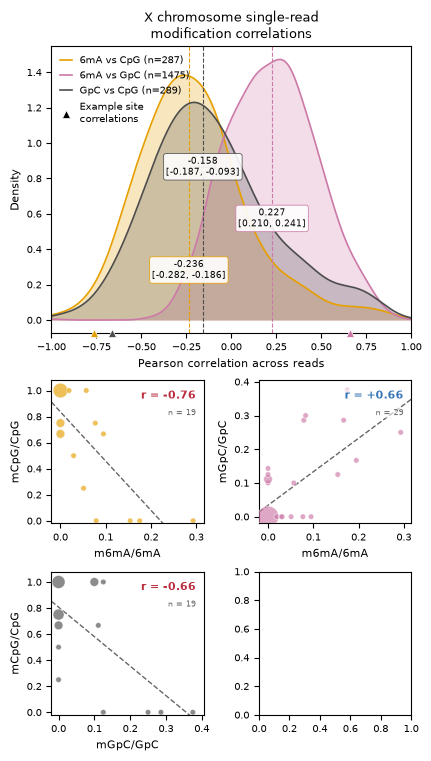

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from scipy.stats import gaussian_kde, pearsonr

# --- what to show -----------------------------------------------------------
FEATURED_SITE       = "chrX:130065923-130066324"   # example site (B/C/D)
TARGET_CHROM        = "chrX"                        # population for the KDE (A)
MARK_EXAMPLE_ON_KDE = True   # drop a caret on A at each comparison's r for this site

# resolve the population key (KDE is over the full population, not the 6 examples)
if TARGET_CHROM not in motif_read_region_mod_fracs_dict:
    cand = [k for k in motif_read_region_mod_fracs_dict if "X" in str(k)]
    TARGET_CHROM = cand[0] if cand else next(iter(motif_read_region_mod_fracs_dict))

pop_fracs  = motif_read_region_mod_fracs_dict[TARGET_CHROM]
site_fracs = motif_read_sites_mod_fracs_dict[FEATURED_SITE]

# --- mosaic -----------------------------------------------------------------
mosaic = """
AAAA
AAAA
BBCC
DDEE
"""
fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(4.2, 7.5), layout="constrained")

# --- A: population KDE, disambiguated CpG (WCG) -----------------------------
boot_rng    = np.random.default_rng(BOOT_SEED)
shuffle_rng = np.random.default_rng(SHUFFLE_SEED)

axA = ax_dict["A"]
compute_and_plot(axA, pop_fracs, panel_comparisons("WCG,1", "WCG"),
                 boot_rng, shuffle_rng, TARGET_CHROM)
axA.set_xlim((-1, 1))
axA.set_xlabel("Pearson correlation across reads")
axA.set_ylabel("Density")
axA.set_title(f"X chromosome single-read\nmodification correlations")
handles, labels = axA.get_legend_handles_labels()   # the three WCG KDE curves
if MARK_EXAMPLE_ON_KDE:
    example_proxy = Line2D(
        [], [], linestyle="none", marker="^", markersize=6,
        markerfacecolor="0.0", markeredgecolor="white", markeredgewidth=0.5,
        label="Example site\ncorrelations",
    )
    handles.append(example_proxy)
    labels.append(example_proxy.get_label())
axA.legend(handles, labels, loc="upper left", handlelength=1.2)

# --- B/C/D: single-site example scatters ------------------------------------
# `comparisons` order matches panel_comparisons(): 6mA-CpG, 6mA-GpC, GpC-CpG,
# so B/C/D colors line up with the KDE curves in A.
for ax_key, (mx, nx, my, ny, color) in zip(["B", "C", "D"], comparisons):
    scatter_pair(ax_dict[ax_key], pair_site(site_fracs, mx, my), nx, ny, color)

# --- optional: mark where THIS site sits in the population distribution ------
# uses the same k>=MIN_VALID filter + Pearson as the KDE, so the caret and the
# scatter's r are the same number, placed on the same-color curve.
if MARK_EXAMPLE_ON_KDE:
    trans = mtransforms.blended_transform_factory(axA.transData, axA.transAxes)
    for (mx, nx, my, ny, color) in comparisons:
        p = pair_site(site_fracs, mx, my)
        xv, yv = p["mod_frac_x"].to_numpy(), p["mod_frac_y"].to_numpy()
        if len(xv) >= 3 and np.ptp(xv) > 0 and np.ptp(yv) > 0:
            r = pearsonr(xv, yv)[0]
            axA.plot([r], [0.0], marker="^", markersize=6, color=color,
                     markeredgecolor="white", markeredgewidth=0.5,
                     transform=trans, clip_on=False, zorder=6)

# ax_dict["B"].set_title(f"Example site\nat Firre locus", fontsize=9)

safe = FEATURED_SITE.replace(":", "_")
save_panel(fig, f"{TARGET_CHROM}_WCG_kde_with_{safe}_scatters")
plt.show()

In [34]:
FEATURED_SITE       = "chrX:130065923-130066324"   # example site (B/C/D)
load_window_size = 100
fig = plot_read_browser.plot_read_browser(
    mod_file_name=output_dir / f"extract.{ctcf_output_id}" / "reads.combined_basemods.h5",
    motifs=["A,0", "GCH,1", "WCG,1"],
    region=FEATURED_SITE,
    thresh=0.75,
    window_size=load_window_size,
    span_full_window=True,
    width=0.8,
    # size=4,
    sort_by="WCG,1_mod_fraction"
)
fig.update_layout(
    width=200,# these values are in pixels
    height=250,    
    margin=dict(t=10, b=10, l=10, r=10),
    title={
        'text': "",
        'x': 0.5,
        'xanchor': 'center',
        'y': 0.9,  # Adjust the vertical position of the title
        'yanchor': 'top',
        'pad': {'b': 10} 
    },
    xaxis_title='chrX position',
    yaxis_title='reads',
    font=dict(color='black')
)
fig.update_traces(marker_showscale=False)
fig.update_xaxes(
    ticks="outside",          # THE key one — draws the actual tick marks
    ticklen=5,                # length of each tick in px
    tickwidth=1,
    tickcolor="black",
    tickangle=0,              # horizontal labels
    showline=True,            # the axis baseline
    linecolor="black",
    linewidth=1,
    tickfont=dict(size=10, color="black"),
    nticks=4,                 # roughly matches the spacing in your target
)
fig.write_image(config.figure_dir / f"single_read_sorted_{FEATURED_SITE.replace(':', '_').replace('-', '_')}.svg", format="svg", scale=2)
fig.show()